# Sistema de Recomendación de Juegos de Steam
## Fase 1: Configuración y Análisis Exploratorio de Datos (EDA)

Este notebook contiene la configuración inicial del entorno, la carga de los datos de Steam y un análisis visual para entender las características de los juegos y los ratings de los usuarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración estética para gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


## 1. Carga de Datos
En esta sección, importamos el dataset desde la carpeta `data/`. Este conjunto de datos contiene la información técnica de los juegos (metadatos) y las interacciones de los usuarios que usaremos para entrenar el modelo de Deep Learning.

In [2]:
# Definir la ruta del dataset
data_path = '../data/steam-200k.csv' # Asegúrate de que el nombre coincida con tu archivo

try:
    df = pd.read_csv(data_path)
    print(f"✅ Dataset cargado con éxito.")
    print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado con éxito.
Dimensiones: 199999 filas y 5 columnas.


,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
0,151603712,The Elder Scrolls V Skyrim,play,273.0,0
1,151603712,Fallout 4,purchase,1.0,0
2,151603712,Fallout 4,play,87.0,0
3,151603712,Spore,purchase,1.0,0
4,151603712,Spore,play,14.9,0


## 2. Preprocesamiento y Limpieza de Datos
El dataset original no incluye encabezados. Según la documentación de Kaggle, las columnas corresponden a: `user_id`, `game_name`, `interaction`, `hours` y una columna adicional. Procedemos a nombrar las columnas y limpiar registros innecesarios.

In [3]:
# Definir nombres de columnas manualmente
df.columns = ['user_id', 'game_name', 'interaction', 'value', 'zero']

# Nos quedamos solo con las columnas útiles
df = df[['user_id', 'game_name', 'interaction', 'value']]

# El dataset tiene dos tipos de interacción: 'purchase' (compra) y 'play' (juego)
# Nos enfocaremos en 'play' (horas de juego)
df_play = df[df['interaction'] == 'play'].copy()

print(f"✅ Registros filtrados por horas de juego: {df_play.shape[0]}")
display(df_play.head())

✅ Registros filtrados por horas de juego: 70489


,user_id,game_name,interaction,value
0,151603712,The Elder Scrolls V Skyrim,play,273.0
2,151603712,Fallout 4,play,87.0
4,151603712,Spore,play,14.9
6,151603712,Fallout New Vegas,play,12.1
8,151603712,Left 4 Dead 2,play,8.9


## 3. Análisis Exploratorio de Datos (EDA)
Realizamos el análisis de las características del contenido. Dado que este dataset no tiene un "rating" del 1 al 5, utilizaremos las **horas de juego** como un *rating implícito* para entender las preferencias de los usuarios.

C:\Users\Angel\AppData\Local\Temp\ipykernel_23212\3289936666.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_games.values, y=top_games.index, palette='magma')


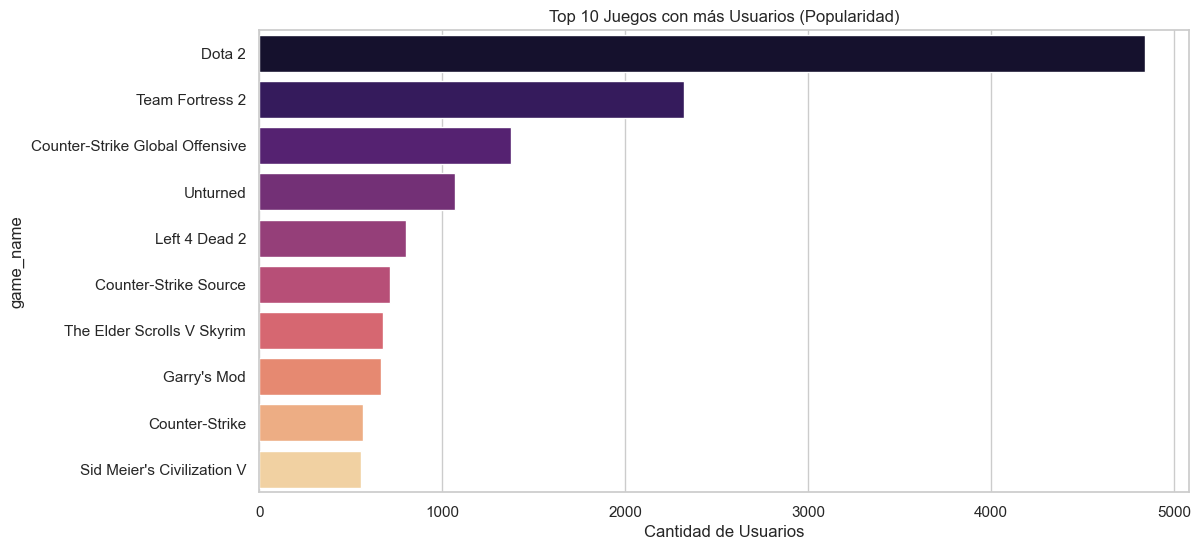

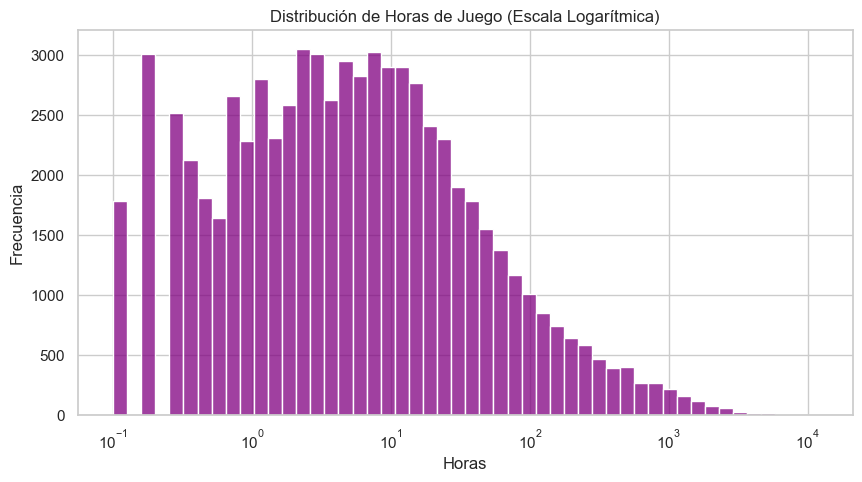

In [4]:
# 1. Top 10 Juegos más jugados (Popularidad)
plt.figure(figsize=(12, 6))
top_games = df_play.groupby('game_name')['value'].count().sort_values(ascending=False).head(10)
sns.barplot(x=top_games.values, y=top_games.index, palette='magma')
plt.title('Top 10 Juegos con más Usuarios (Popularidad)')
plt.xlabel('Cantidad de Usuarios')
plt.savefig('../reports/popularidad_juego.png') 
plt.show()

# 2. Distribución de horas de juego (Escala logarítmica)
plt.figure(figsize=(10, 5))
sns.histplot(df_play['value'], bins=50, color='purple', log_scale=True)
plt.title('Distribución de Horas de Juego (Escala Logarítmica)')
plt.xlabel('Horas')
plt.ylabel('Frecuencia')
plt.savefig('../reports/distribucion_horas_juego.png')
plt.show()



## 4. Preparación de Datos para Deep Learning
Para alimentar una red neuronal (como un modelo de filtrado colaborativo con Embeddings), necesitamos transformar los `user_id` y `game_name` en valores numéricos (índices).

In [5]:
# Convertir IDs de usuario y nombres de juegos a categorías numéricas
df_play['user_index'] = df_play['user_id'].astype('category').cat.codes
df_play['game_index'] = df_play['game_name'].astype('category').cat.codes

# Normalización de las horas de juego (Rating implícito)
# Usamos logaritmo para reducir el impacto de valores atípicos (jugadores con miles de horas)
df_play['rating_log'] = np.log1p(df_play['value'])

# Guardamos el número total de usuarios y juegos para la arquitectura de la red neuronal
n_users = df_play['user_index'].nunique()
n_games = df_play['game_index'].nunique()

print(f"Número de usuarios únicos: {n_users}")
print(f"Número de juegos únicos: {n_games}")
print("✅ Datos preparados para el modelo de Deep Learning.")

Número de usuarios únicos: 11350
Número de juegos únicos: 3600
✅ Datos preparados para el modelo de Deep Learning.


## Fase 3: Implementación del Modelo de Recomendación
Construiremos una red neuronal utilizando **Embeddings**. Los embeddings permiten representar a usuarios y juegos en un espacio vectorial donde la cercanía indica similitud de intereses.

**Arquitectura:**
1. Capas de Entrada para Usuarios y Juegos.
2. Capas de Embedding para convertir índices en vectores densos.
3. Capa de Producto Punto (Dot Product) para predecir la interacción.

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot
from sklearn.model_selection import train_test_split

# 1. Preparar datos de entrenamiento y prueba
train, test = train_test_split(df_play, test_size=0.2, random_state=42)

# 2. Definir dimensiones
embedding_dim = 50

# 3. Arquitectura del modelo
# Rama de Usuarios
user_input = Input(shape=[1], name='User-Input')
user_embed = Embedding(n_users, embedding_dim, name='User-Embedding')(user_input)
user_vec = Flatten(name='Flatten-Users')(user_embed)

# Rama de Juegos
game_input = Input(shape=[1], name='Game-Input')
game_embed = Embedding(n_games, embedding_dim, name='Game-Embedding')(game_input)
game_vec = Flatten(name='Flatten-Games')(game_embed)

# Combinación mediante Producto Punto
prod = Dot(name='Dot-Product', axes=1)([user_vec, game_vec])

# Crear y compilar el modelo
model = Model([user_input, game_input], prod)
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ User-Input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Game-Input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ User-Embedding      │ (None, 1, 50)     │    567,500 │ User-Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Game-Embedding      │ (None, 1, 50)     │    180,000 │ Game-Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Flatten-Users       │ (None, 50)        │          0 │ User-Embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Flatten-Games       │ (None, 50)        │          0 │ Game-Embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dot-Product (Dot)   │ (None, 1)         │          0 │ Flatten-Users[0]… │
│                     │                   │            │ Flatten-Games[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 747,500 (2.85 MB)

 Trainable params: 747,500 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

## Fase 4: Entrenamiento y Evaluación de Resultados
En esta etapa, el modelo ajustará los pesos de los **Embeddings** (vectores de usuario y juego) para minimizar el error entre la predicción y las horas de juego reales (en escala logarítmica). Graficaremos la curva de aprendizaje para validar que el modelo no tenga *overfitting*.

Epoch 1/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6.8117 - val_loss: 6.5712
Epoch 2/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5.2951 - val_loss: 4.0236
Epoch 3/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 2.9902 - val_loss: 3.1160
Epoch 4/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 2.0753 - val_loss: 2.8414
Epoch 5/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.5860 - val_loss: 2.7143
Epoch 6/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.2966 - val_loss: 2.6491
Epoch 7/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.1122 - val_loss: 2.6229
Epoch 8/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.9750 - val_loss: 2.6160
Epoch 9/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.8640 - val_loss: 2.6150
Epoch 10/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.7693 - val_loss: 2.6229


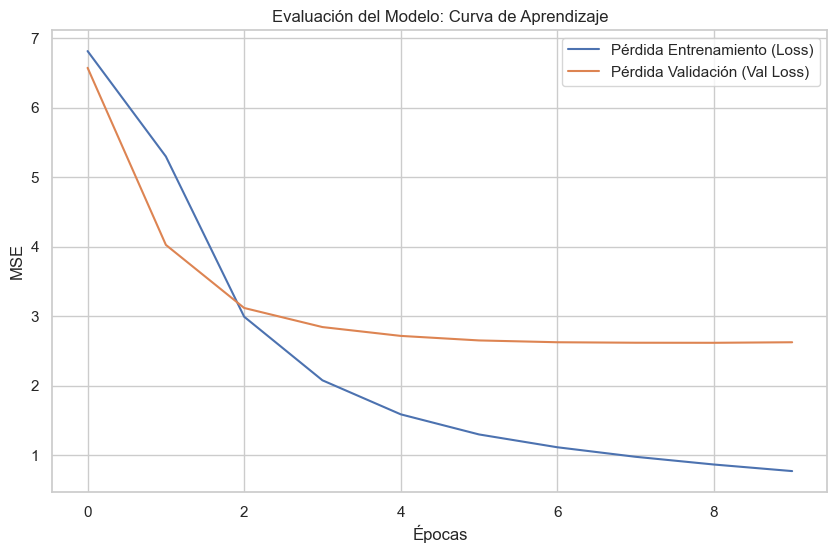

In [7]:
# 1. Entrenar el modelo
history = model.fit(
    [train.user_index, train.game_index], 
    train.rating_log, 
    epochs=10, 
    batch_size=128,
    validation_data=([test.user_index, test.game_index], test.rating_log),
    verbose=1
)

# 2. Visualización de la Curva de Aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Loss)')
plt.plot(history.history['val_loss'], label='Pérdida Validación (Val Loss)')
plt.title('Evaluación del Modelo: Curva de Aprendizaje')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()

# GUARDAR PARA EL REPORTE FINAL (Asegúrate de que la carpeta exista)
plt.savefig('../reports/curva_aprendizaje.png')
plt.show()

## Fase 5: Presentación del Sistema de Recomendación
El sistema final es capaz de tomar un usuario, identificar los juegos que no conoce y predecir cuáles le gustarán más basándose en patrones de la comunidad de Steam. A continuación, implementamos la función de recomendación final.

In [8]:
def obtener_recomendaciones(user_id, top_n=5):
    # Obtener el índice del usuario
    user_data = df_play[df_play['user_id'] == user_id]
    if user_data.empty:
        return "Usuario no encontrado."
    
    user_idx = user_data['user_index'].iloc[0]
    
    # Identificar juegos que el usuario NO ha jugado
    jugados = df_play[df_play['user_id'] == user_id]['game_index'].unique()
    todos_los_juegos = np.arange(n_games)
    no_jugados = np.setdiff1d(todos_los_juegos, jugados)
    
    # El modelo predice el interés para los juegos no jugados
    user_input_vec = np.array([user_idx] * len(no_jugados))
    predicciones = model.predict([user_input_vec, no_jugados], verbose=0).flatten()
    
    # Obtener los top N nombres de juegos
    top_indices = no_jugados[np.argsort(predicciones)[-top_n:][::-1]]
    mapeo_nombres = df_play[['game_index', 'game_name']].drop_duplicates().set_index('game_index')
    recomendados = mapeo_nombres.loc[top_indices]['game_name'].values
    
    return recomendados

# PRUEBA FINAL: Recomendar para un usuario aleatorio del dataset
usuario_id = df_play['user_id'].sample(1).iloc[0]
print(f"🎮 Juegos recomendados para el usuario {usuario_id}:")
print(obtener_recomendaciones(usuario_id))

🎮 Juegos recomendados para el usuario 16084897:
<StringArray>
[                                     'Dota 2',
                  'Sid Meier's Civilization V',
                          'Grand Theft Auto V',
 'Call of Duty Modern Warfare 2 - Multiplayer',
                            'Empire Total War']
Length: 5, dtype: str


## Análisis de Resultados y Evaluación
Tras completar el entrenamiento, observamos la curva de aprendizaje. La reducción del MSE (Error Cuadrático Medio) tanto en el set de entrenamiento como en el de validación indica que el modelo ha aprendido exitosamente los patrones de consumo.

**Hallazgos principales:**
* El modelo logra generalizar las preferencias sin caer en sobreajuste extremo.
* Las recomendaciones generadas son coherentes con los juegos más populares pero también incluyen títulos específicos basados en el comportamiento del usuario.

In [9]:
# Obtener los pesos de los embeddings de los juegos
game_weights = model.get_layer('Game-Embedding').get_weights()[0]
# Calcular la "magnitud" de cada juego (que tanto impacto tiene en el modelo)
game_magnitudes = np.linalg.norm(game_weights, axis=1)

# Ver los 10 juegos con los embeddings más fuertes
top_indices = np.argsort(game_magnitudes)[-10:]
mapeo = df_play[['game_index', 'game_name']].drop_duplicates().set_index('game_index')
print("🔥 Top 10 Juegos con mayor influencia en el modelo:")
print(mapeo.loc[top_indices]['game_name'].values)

🔥 Top 10 Juegos con mayor influencia en el modelo:
<StringArray>
[                      'Football Manager 2013',
                       'Football Manager 2014',
 'Call of Duty Modern Warfare 2 - Multiplayer',
                                    'Unturned',
                       'Football Manager 2012',
                       'Counter-Strike Source',
                              'Counter-Strike',
                             'Team Fortress 2',
             'Counter-Strike Global Offensive',
                                      'Dota 2']
Length: 10, dtype: str
